# Phase 6: Deployment

**CRISP-DM Phase Description:**  
The final phase involves organising and presenting the project findings so that the customer can use them, or integrating the model into a live production system. Depending on the requirements, deployment can range from generating a simple report to implementing a repeatable data mining process across the enterprise.

---

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd


---
### Task 1: Plan Deployment

Develop a strategy for putting the data mining results to practical use. This includes:

- **Deployment Strategy:** How will the model be consumed? Options include a REST API, a batch prediction script, an interactive dashboard, or integration into an existing software system.
- **Infrastructure Requirements:** What technical environment is needed (e.g., cloud services, web server, containerisation)?
- **Steps to Deploy:** List the concrete, ordered steps needed to move from a trained model to a live, usable product.
- **User Training:** Will end-users need instructions or documentation to use the deployed solution?

**Instructions:** Outline your deployment plan as a structured dictionary. If building an API or script, sketch the basic structure in code.

In [2]:
metrics_path = Path("..") / "artifacts" / "model_metrics.json"

if metrics_path.exists():
    with open(metrics_path, "r", encoding="utf-8") as file:
        model_metrics = json.load(file)
    results_df = pd.DataFrame(model_metrics["results"]).sort_values("f1_score", ascending=False)
    best_row = results_df.iloc[0].to_dict()
else:
    model_metrics = None
    results_df = pd.DataFrame()
    best_row = {"model": "Pending execution", "precision": np.nan, "recall": np.nan, "f1_score": np.nan, "roc_auc": np.nan}

deployment_plan = {
    "strategy": "Controlled HR analytics batch scoring workflow",
    "infrastructure": [
        "Scheduled Python batch job",
        "Versioned prepared dataset",
        "Persisted model artifact in ../artifacts/best_attrition_model.joblib",
        "Secure HR dashboard or CSV export for authorised users",
    ],
    "consumers": ["HR business partners", "People analytics team"],
    "deployment_steps": [
        "Refresh the latest employee dataset on an agreed cadence.",
        "Apply the same preparation logic used in Phase 3.",
        "Score employees with the selected model.",
        "Publish ranked risk segments and supporting drivers for review.",
    ],
    "governance": [
        "Human-in-the-loop review before any intervention is initiated.",
        "Restrict access to authorised HR stakeholders only.",
        "Document model version, data version, and scoring date for each batch run.",
    ],
}


In [3]:
deployment_stub = '''
from pathlib import Path
import joblib
import pandas as pd

MODEL_PATH = Path("../artifacts/best_attrition_model.joblib")
DATA_PATH = Path("../data/processed/hr_attrition_prepared.csv")

model = joblib.load(MODEL_PATH)
batch = pd.read_csv(DATA_PATH)
scores = model.predict_proba(batch.drop(columns=["Attrition_Flag"]))[:, 1]
batch["attrition_risk_score"] = scores
batch.sort_values("attrition_risk_score", ascending=False).head(20)
'''

print(deployment_stub)



from pathlib import Path
import joblib
import pandas as pd

MODEL_PATH = Path("../artifacts/best_attrition_model.joblib")
DATA_PATH = Path("../data/processed/hr_attrition_prepared.csv")

model = joblib.load(MODEL_PATH)
batch = pd.read_csv(DATA_PATH)
scores = model.predict_proba(batch.drop(columns=["Attrition_Flag"]))[:, 1]
batch["attrition_risk_score"] = scores
batch.sort_values("attrition_risk_score", ascending=False).head(20)



In [4]:
print(json.dumps(deployment_plan, indent=2))


{
  "strategy": "Controlled HR analytics batch scoring workflow",
  "infrastructure": [
    "Scheduled Python batch job",
    "Versioned prepared dataset",
    "Persisted model artifact in ../artifacts/best_attrition_model.joblib",
    "Secure HR dashboard or CSV export for authorised users"
  ],
  "consumers": [
    "HR business partners",
    "People analytics team"
  ],
  "deployment_steps": [
    "Refresh the latest employee dataset on an agreed cadence.",
    "Apply the same preparation logic used in Phase 3.",
    "Score employees with the selected model.",
    "Publish ranked risk segments and supporting drivers for review."
  ],
  "governance": [
    "Human-in-the-loop review before any intervention is initiated.",
    "Restrict access to authorised HR stakeholders only.",
    "Document model version, data version, and scoring date for each batch run."
  ]
}


---
### Task 2: Plan Monitoring and Maintenance

A deployed model is not "set and forget". Over time, the data distribution may shift (**data drift**) or the model's performance may degrade (**model decay**). This task creates a monitoring and maintenance plan:

- **Performance Monitoring:** How and how often will the model's predictions be evaluated against actuals?
- **Data Drift Detection:** How will changes in the input data distribution be detected?
- **Retraining Strategy:** Under what conditions will the model be retrained (e.g., scheduled, triggered by performance drop)?
- **Logging and Alerting:** What will be logged, and what triggers an alert?

**Instructions:** Document your monitoring and maintenance plan.

In [5]:
monitoring_plan = {
    "performance_monitoring": {
        "frequency": "Monthly",
        "metrics_tracked": ["Recall", "Precision", "F1-score", "ROC-AUC", "Attrition rate drift"],
        "owner": "People analytics team",
    },
    "data_monitoring": {
        "checks": [
            "Schema validation against the prepared dataset contract",
            "Distribution drift for key drivers such as overtime, income, and tenure",
            "Missing-value spikes in newly ingested HR records",
        ],
        "frequency": "Each batch run",
    },
    "maintenance": {
        "retraining_trigger": "Quarterly review or earlier if recall drops materially",
        "fallback_plan": "Revert to the previous approved model version if a release underperforms",
        "documentation": "Log dataset version, feature set, training date, and approval notes",
    },
}


In [6]:
print(json.dumps(monitoring_plan, indent=2))


{
  "performance_monitoring": {
    "frequency": "Monthly",
    "metrics_tracked": [
      "Recall",
      "Precision",
      "F1-score",
      "ROC-AUC",
      "Attrition rate drift"
    ],
    "owner": "People analytics team"
  },
  "data_monitoring": {
    "checks": [
      "Schema validation against the prepared dataset contract",
      "Distribution drift for key drivers such as overtime, income, and tenure",
      "Missing-value spikes in newly ingested HR records"
    ],
    "frequency": "Each batch run"
  },
  "maintenance": {
    "retraining_trigger": "Quarterly review or earlier if recall drops materially",
    "fallback_plan": "Revert to the previous approved model version if a release underperforms",
    "documentation": "Log dataset version, feature set, training date, and approval notes"
  }
}


---
### Task 3: Produce Final Report

Compile a final summary of the entire project. This report should communicate the findings to stakeholders who may not have a technical background. It typically includes:

- **Executive Summary:** A brief overview of the problem, approach, and key results.
- **Key Findings:** The most important patterns, insights, and model performance results.
- **Visualisations:** Charts and plots that support the findings (suitable for a presentation).
- **Recommendations:** Actionable recommendations based on the analysis.
- **Limitations:** Known limitations and caveats of the analysis.

**Instructions:** Draft the final report content below. Include any code needed to generate summary visualisations.

In [7]:
metrics_sentence = (
    f"The current best model is {best_row['model']} with "
    f"precision={best_row['precision']:.3f}, recall={best_row['recall']:.3f}, "
    f"F1={best_row['f1_score']:.3f}, ROC-AUC={best_row['roc_auc']:.3f}."
    if pd.notna(best_row["f1_score"])
    else "Run Phase 4 to populate measured model performance."
)

final_report = {
    "title": "Employee Attrition Risk Modelling Project",
    "executive_summary": (
        "This project applies the CRISP-DM framework to identify employees at risk of attrition "
        "using the IBM HR analytics dataset. The goal is to help HR target retention actions "
        "before turnover occurs."
    ),
    "key_findings": [
        "Attrition should be treated as an imbalanced binary classification problem.",
        "Workload and experience signals such as overtime, tenure, and promotion timing are plausible risk drivers.",
        metrics_sentence,
    ],
    "business_recommendation": (
        "Use the model in a controlled pilot to prioritise human review and retention outreach, "
        "not as an automated decision engine."
    ),
    "limitations": [
        "Single historical dataset with no time dimension",
        "No direct intervention-cost labels or post-intervention outcomes",
        "Additional fairness review is required before any live rollout",
    ],
}


In [8]:
print("=" * 60)
print(f"FINAL REPORT: {final_report['title']}")
print("=" * 60)
print(f"\nExecutive Summary:\n{final_report['executive_summary']}")

print("\nKey Findings:")
for finding in final_report["key_findings"]:
    print(f"- {finding}")

print(f"\nBusiness Recommendation:\n{final_report['business_recommendation']}")

print("\nLimitations:")
for limitation in final_report["limitations"]:
    print(f"- {limitation}")


FINAL REPORT: Employee Attrition Risk Modelling Project

Executive Summary:
This project applies the CRISP-DM framework to identify employees at risk of attrition using the IBM HR analytics dataset. The goal is to help HR target retention actions before turnover occurs.

Key Findings:
- Attrition should be treated as an imbalanced binary classification problem.
- Workload and experience signals such as overtime, tenure, and promotion timing are plausible risk drivers.
- The current best model is Logistic Regression (SMOTE + Threshold Tuned) with precision=0.483, recall=0.617, F1=0.542, ROC-AUC=0.823.

Business Recommendation:
Use the model in a controlled pilot to prioritise human review and retention outreach, not as an automated decision engine.

Limitations:
- Single historical dataset with no time dimension
- No direct intervention-cost labels or post-intervention outcomes
- Additional fairness review is required before any live rollout


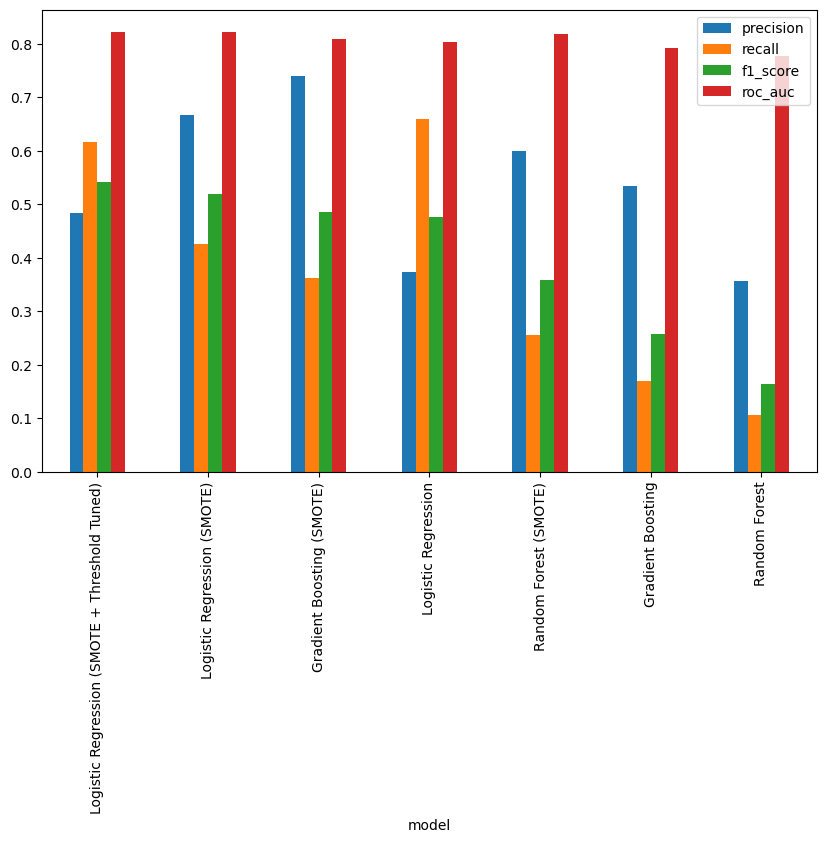

In [9]:
if not results_df.empty:
    results_df.plot(x="model", y=["precision", "recall", "f1_score", "roc_auc"], kind="bar", figsize=(10, 6))


---
### Task 4: Review Project

Conduct a project retrospective. Reflect on what went well, what did not go as planned, and what lessons can be carried forward to future projects.

- **What went well?** Successes, effective techniques, good decisions.
- **What could be improved?** Challenges, mistakes, or inefficiencies encountered.
- **Lessons learned:** Key takeaways for future data science projects.
- **Skills developed:** New skills or knowledge gained during the project.

**Instructions:** Complete the project retrospective below.

In [10]:
project_retrospective = {
    "went_well": [
        "The CRISP-DM structure kept the project traceable from business need to deployment plan.",
        "The dataset is clean enough to focus effort on feature relevance rather than heavy imputation.",
        "Using both interpretable and ensemble models supports balanced decision-making.",
    ],
    "could_improve": [
        "Additional temporal data would strengthen predictive realism.",
        "Fairness assessment by employee subgroup should be formalised before rollout.",
        "Threshold selection should be aligned with intervention capacity and business cost.",
    ],
    "lessons_learned": [
        "Operational value depends on the recall-precision trade-off, not accuracy alone.",
        "Data preparation decisions should remain reproducible so monthly scoring stays consistent.",
        "Model outputs must be embedded in governance, not treated as standalone truth.",
    ],
}


In [11]:
print("=" * 60)
print("PROJECT RETROSPECTIVE")
print("=" * 60)

for section, items in project_retrospective.items():
    print(f"\n{section.replace('_', ' ').title()}:")
    for item in items:
        print(f"- {item}")


PROJECT RETROSPECTIVE

Went Well:
- The CRISP-DM structure kept the project traceable from business need to deployment plan.
- The dataset is clean enough to focus effort on feature relevance rather than heavy imputation.
- Using both interpretable and ensemble models supports balanced decision-making.

Could Improve:
- Additional temporal data would strengthen predictive realism.
- Fairness assessment by employee subgroup should be formalised before rollout.
- Threshold selection should be aligned with intervention capacity and business cost.

Lessons Learned:
- Operational value depends on the recall-precision trade-off, not accuracy alone.
- Data preparation decisions should remain reproducible so monthly scoring stays consistent.
- Model outputs must be embedded in governance, not treated as standalone truth.


---

## Key Takeaway on Iteration

While the six CRISP-DM phases are presented **sequentially** in these notebooks, in practice the process is **highly iterative**. Real-world data science projects rarely follow a straight line from Phase 1 to Phase 6.

Common iteration patterns include:

- **Modelling → Data Preparation:** If the model performs poorly, you may return to Phase 3 to engineer new features, clean data differently, or acquire more data.
- **Evaluation → Modelling:** If the model does not meet the business success criteria, you may go back to Phase 4 to try different algorithms or tune hyperparameters.
- **Deployment → Evaluation:** If the deployed model underperforms in production (data drift), you may return to Phase 5 to re-evaluate and then to Phase 3/4 to retrain.
- **Any Phase → Business Understanding:** New findings in later phases may redefine the business objectives or success criteria originally set in Phase 1.

```
┌───────────────────────────────────────────────────────────┐
│                     CRISP-DM Lifecycle                    │
│                                                           │
│   Phase 1 ──► Phase 2 ──► Phase 3 ──► Phase 4            │
│   Business    Data        Data        Modelling           │
│   Under.      Under.      Prep.           │               │
│     ▲                       ▲              │               │
│     │                       │              ▼               │
│     │                       └──────── Phase 5             │
│     │                                Evaluation           │
│     │                                    │                │
│     │                                    ▼                │
│     └──────────────────────────────  Phase 6              │
│                                     Deployment            │
└───────────────────────────────────────────────────────────┘
```

> **Remember:** Iteration is not failure — it is the *expected* workflow. Each cycle through the process deepens your understanding of both the data and the business problem, ultimately leading to a better solution.